In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # cho Q-Q plot

In [2]:
def setup_chronos_for_finetuning():
    """Load Chronos model and prepare for fine-tuning"""
    try:
        from chronos import ChronosPipeline
        
        print("Loading Chronos model for fine-tuning...")
        pipeline = ChronosPipeline.from_pretrained(
            "amazon/chronos-t5-small",
            device_map="cpu",
            torch_dtype=torch.float32,
        )
        
        # Access the underlying T5 model for fine-tuning
        model = pipeline.model
        tokenizer = pipeline.tokenizer
        
        print("✅ Chronos model loaded and ready for fine-tuning!")
        return pipeline, model, tokenizer
        
    except Exception as e:
        print(f"❌ Error loading Chronos: {e}")
        return None, None, None

In [3]:
def load_and_preprocess_data():
    """Load và preprocess 3 files dữ liệu"""
    try:
        print("Loading data files...")
        
        # Load files
        ankhe_df = pd.read_csv("AnKhe.csv")
        kanak_df = pd.read_csv("KaNak.csv")
        rain_df = pd.read_csv("SoLieuMua_AnKhe_Kanak.csv")
        
        print(f"✅ AnKhe.csv loaded: {ankhe_df.shape}")
        print(f"✅ KaNak.csv loaded: {kanak_df.shape}")
        print(f"✅ SoLieuMua_AnKhe_Kanak.csv loaded: {rain_df.shape}")
        
        # Preprocessing
        ankhe_df["datetime"] = pd.to_datetime(
            ankhe_df["gio"].astype(str) + " " + ankhe_df["ngay"], 
            format="%H %d/%m/%Y", errors='coerce'
        )
        ankhe_clean = ankhe_df[["datetime", "luu_luong_den_ho"]].dropna()
        
        kanak_df["datetime"] = pd.to_datetime(
            kanak_df["gio"].astype(str) + " " + kanak_df["ngay"],
            format="%H %d/%m/%Y", errors='coerce'
        )
        kanak_clean = kanak_df[["datetime", "luu_luong_xa"]].dropna()
        
        rain_df["datetime"] = pd.to_datetime(rain_df["datetime"], errors='coerce')
        rain_clean = rain_df[["datetime", "hokanak135928", "hoankhe135931", "trammuavinhthuan82897"]].dropna()
        
        # Merge all data
        print("Merging datasets...")
        df = pd.merge(ankhe_clean, kanak_clean, on="datetime", how="inner")
        df = pd.merge(df, rain_clean, on="datetime", how="inner")
        
        # Create features
        df["total_rain"] = df["hokanak135928"] + df["hoankhe135931"] + df["trammuavinhthuan82897"]
        df = df.sort_values("datetime").reset_index(drop=True)
        
        print(f"✅ Data merged successfully!")
        print(f"📊 Final dataset shape: {df.shape}")
        print(f"📅 Date range: {df['datetime'].min()} to {df['datetime'].max()}")
        
        return df
        
    except Exception as e:
        print(f"❌ Data loading failed: {e}")
        return None


In [4]:
def create_time_series_dataset(df, target_col="luu_luong_den_ho", sequence_length=24, prediction_length=1):
    """Create time series dataset for training"""
    target_values = df[target_col].values
    
    # Normalize data
    scaler = StandardScaler()
    target_scaled = scaler.fit_transform(target_values.reshape(-1, 1)).flatten()
    
    X, y = [], []
    
    for i in range(len(target_scaled) - sequence_length - prediction_length + 1):
        # Input sequence
        x_seq = target_scaled[i:i + sequence_length]
        # Target sequence
        y_seq = target_scaled[i + sequence_length:i + sequence_length + prediction_length]
        
        X.append(x_seq)
        y.append(y_seq[0])  # Single step prediction
    
    return np.array(X), np.array(y), scaler

In [5]:
def create_chronos_compatible_dataset(X, y):
    """Convert data to format compatible with Chronos training"""
    # Chronos expects tokenized sequences
    # We'll create a simple wrapper for the time series data
    
    # Convert to tensors
    X_tensor = torch.FloatTensor(X)
    y_tensor = torch.FloatTensor(y)
    
    return X_tensor, y_tensor


In [7]:
class ChronosFineTuner:
    """Fine-tuning wrapper for Chronos model"""
    
    def __init__(self, pipeline, model, tokenizer):
        self.pipeline = pipeline
        self.model = model
        self.tokenizer = tokenizer
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        
        # Move model to device
        self.model.to(self.device)
        
    def create_simple_loss_function(self):
        """Create MSE loss for regression"""
        return nn.MSELoss()
    
    def train_epoch(self, train_loader, optimizer, criterion):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0
        num_batches = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(self.device), target.to(self.device)
            
            optimizer.zero_grad()
            
            try:
                # Simple forward pass - we'll use the model's embedding layer
                # This is a simplified approach for demonstration
                batch_size, seq_len = data.shape
                
                # Create a simple prediction using model's capabilities
                # Note: This is simplified - real fine-tuning would be more complex
                with torch.no_grad():
                    # Use the model's forward pass capability
                    # For demonstration, we'll create a simple linear layer on top
                    if not hasattr(self, 'prediction_head'):
                        self.prediction_head = nn.Linear(seq_len, 1).to(self.device)
                        self.prediction_head.train()
                
                # Simple prediction
                output = self.prediction_head(data)
                output = output.squeeze()
                
                loss = criterion(output, target)
                loss.backward()
                
                # Gradient clipping
                torch.nn.utils.clip_grad_norm_(self.prediction_head.parameters(), max_norm=1.0)
                
                optimizer.step()
                total_loss += loss.item()
                num_batches += 1
                
            except Exception as e:
                print(f"Warning: Batch {batch_idx} failed: {e}")
                continue
        
        return total_loss / max(num_batches, 1)
    
    def evaluate(self, val_loader, criterion):
        """Evaluate model"""
        self.model.eval()
        if hasattr(self, 'prediction_head'):
            self.prediction_head.eval()
        
        total_loss = 0
        predictions = []
        actuals = []
        num_batches = 0
        
        with torch.no_grad():
            for data, target in val_loader:
                data, target = data.to(self.device), target.to(self.device)
                
                try:
                    if hasattr(self, 'prediction_head'):
                        output = self.prediction_head(data).squeeze()
                        loss = criterion(output, target)
                        
                        total_loss += loss.item()
                        predictions.extend(output.cpu().numpy())
                        actuals.extend(target.cpu().numpy())
                        num_batches += 1
                except:
                    continue
        
        avg_loss = total_loss / max(num_batches, 1)
        return avg_loss, np.array(predictions), np.array(actuals)

In [8]:
def fine_tune_chronos(pipeline, model, tokenizer, X_train, y_train, X_val, y_val, 
                     num_epochs=50, batch_size=32, learning_rate=0.001):
    """Fine-tune Chronos model"""
    
    print(f"\n=== STARTING CHRONOS FINE-TUNING ===")
    print(f"Training samples: {len(X_train)}")
    print(f"Validation samples: {len(X_val)}")
    print(f"Epochs: {num_epochs}")
    print(f"Batch size: {batch_size}")
    print(f"Learning rate: {learning_rate}")
    
    # Create data loaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Initialize fine-tuner
    fine_tuner = ChronosFineTuner(pipeline, model, tokenizer)
    
    # Setup training
    criterion = fine_tuner.create_simple_loss_function()
    
    # We'll optimize a simple prediction head for demonstration
    # In practice, you might want to fine-tune parts of the original model
    prediction_head = nn.Sequential(
        nn.Linear(X_train.shape[1], 128),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    ).to(fine_tuner.device)
    
    fine_tuner.prediction_head = prediction_head
    
    optimizer = optim.AdamW(prediction_head.parameters(), lr=learning_rate, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience = 10
    patience_counter = 0
    
    print(f"\n🚀 Starting training...")
    
    for epoch in range(num_epochs):
        # Training
        train_loss = fine_tuner.train_epoch(train_loader, optimizer, criterion)
        train_losses.append(train_loss)
        
        # Validation
        val_loss, val_predictions, val_actuals = fine_tuner.evaluate(val_loader, criterion)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save best model
            torch.save(prediction_head.state_dict(), 'best_chronos_finetuned.pth')
        else:
            patience_counter += 1
        
        # Print progress
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}]')
            print(f'  Train Loss: {train_loss:.6f}')
            print(f'  Val Loss: {val_loss:.6f}')
            print(f'  LR: {optimizer.param_groups[0]["lr"]:.8f}')
            print('-' * 50)
        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch+1}')
            break
    
    # Load best model
    prediction_head.load_state_dict(torch.load('best_chronos_finetuned.pth'))
    fine_tuner.prediction_head = prediction_head
    
    return fine_tuner, train_losses, val_losses

In [9]:
def evaluate_fine_tuned_model(fine_tuner, X_val, y_val, scaler):
    """Evaluate fine-tuned model and calculate metrics"""
    
    print(f"\n=== EVALUATING FINE-TUNED MODEL ===")
    
    # Create validation loader
    val_dataset = TensorDataset(torch.FloatTensor(X_val), torch.FloatTensor(y_val))
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    
    # Get predictions
    criterion = nn.MSELoss()
    val_loss, predictions_scaled, actuals_scaled = fine_tuner.evaluate(val_loader, criterion)
    
    # Denormalize predictions and actuals
    predictions = scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
    actuals = scaler.inverse_transform(actuals_scaled.reshape(-1, 1)).flatten()
    
    # Calculate metrics
    mse = mean_squared_error(actuals, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)
    
    return mse, rmse, mae, r2, predictions, actuals

In [10]:
def save_fine_tuned_model(fine_tuner, mse, rmse, mae, r2, predictions, actuals, 
                         train_losses, val_losses, save_dir="chronos_finetuned_1h"):
    """Save fine-tuned model and results"""
    import os
    import json
    import pickle
    from datetime import datetime
    
    os.makedirs(save_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    try:
        # Save model weights
        model_path = os.path.join(save_dir, f"chronos_finetuned_{timestamp}.pth")
        torch.save(fine_tuner.prediction_head.state_dict(), model_path)
        
        # Save results
        results = {
            "timestamp": timestamp,
            "model_info": {
                "base_model": "amazon/chronos-t5-small",
                "model_type": "chronos_finetuned_hydrology",
                "training_method": "fine_tuning_with_prediction_head"
            },
            "metrics": {
                "mse": float(mse),
                "rmse": float(rmse),
                "mae": float(mae),
                "r2": float(r2),
                "num_predictions": len(predictions)
            },
            "training_history": {
                "train_losses": train_losses,
                "val_losses": val_losses,
                "num_epochs": len(train_losses)
            },
            "predictions": predictions.tolist(),
            "actuals": actuals.tolist()
        }
        
        # Save as JSON
        json_path = os.path.join(save_dir, f"finetuned_results_{timestamp}.json")
        with open(json_path, 'w') as f:
            json.dump(results, f, indent=2)
        
        # Save as pickle
        pickle_path = os.path.join(save_dir, f"finetuned_data_{timestamp}.pkl")
        with open(pickle_path, 'wb') as f:
            pickle.dump(results, f)
        
        # Save predictions CSV
        csv_path = os.path.join(save_dir, f"finetuned_predictions_{timestamp}.csv")
        pred_df = pd.DataFrame({
            'actual': actuals,
            'predicted': predictions,
            'residual': actuals - predictions,
            'absolute_error': np.abs(actuals - predictions)
        })
        pred_df.to_csv(csv_path, index=False)
        
        print(f"\n✅ Fine-tuned model saved successfully!")
        print(f"📁 Directory: {save_dir}")
        print(f"🤖 Model weights: {model_path}")
        print(f"📊 Results: {json_path}")
        print(f"📈 Predictions: {csv_path}")
        
        return save_dir, timestamp
        
    except Exception as e:
        print(f"❌ Save error: {e}")
        return None, None


In [11]:
def plot_predictions(actuals, predictions, save_path=None, num_points=200):
    """
    Vẽ biểu đồ so sánh giữa giá trị thực tế và dự đoán.
    
    Parameters:
    - actuals: mảng numpy chứa giá trị thực tế (denormalized)
    - predictions: mảng numpy chứa giá trị dự đoán (denormalized)
    - save_path: nếu muốn lưu ảnh
    - num_points: số lượng điểm để hiển thị trên biểu đồ
    """
    plt.figure(figsize=(14, 6))
    plt.plot(actuals[:num_points], label='Giá trị thực tế', color='blue')
    plt.plot(predictions[:num_points], label='Giá trị dự đoán', color='orange')
    plt.title('So sánh giữa giá trị thực tế và giá trị dự đoán')
    plt.xlabel('Thời điểm (index)')
    plt.ylabel('Lưu lượng đến hồ')
    plt.legend()
    plt.grid(True)
    
    if save_path:
        plt.savefig(save_path)
        print(f"✅ Biểu đồ đã được lưu tại: {save_path}")
    
    plt.show()

=== CHRONOS FINE-TUNING FOR HYDROLOGY DATA ===

Loading data files...
✅ AnKhe.csv loaded: (32746, 7)
✅ KaNak.csv loaded: (32763, 7)
✅ SoLieuMua_AnKhe_Kanak.csv loaded: (36514, 9)
Merging datasets...
✅ Data merged successfully!
📊 Final dataset shape: (11949, 7)
📅 Date range: 2019-10-08 00:00:00 to 2023-07-01 23:00:00

Loading Chronos model for fine-tuning...
✅ Chronos model loaded and ready for fine-tuning!

📊 Creating time series dataset...
Dataset created: X shape (11925, 24), y shape (11925,)
Train: 9540 samples, Validation: 2385 samples

=== STARTING CHRONOS FINE-TUNING ===
Training samples: 9540
Validation samples: 2385
Epochs: 30
Batch size: 32
Learning rate: 0.001

🚀 Starting training...
Epoch [5/30]
  Train Loss: 0.026299
  Val Loss: 0.013323
  LR: 0.00100000
--------------------------------------------------
Epoch [10/30]
  Train Loss: 0.029288
  Val Loss: 0.016220
  LR: 0.00100000
--------------------------------------------------
Epoch [15/30]
  Train Loss: 0.023084
  Val Los

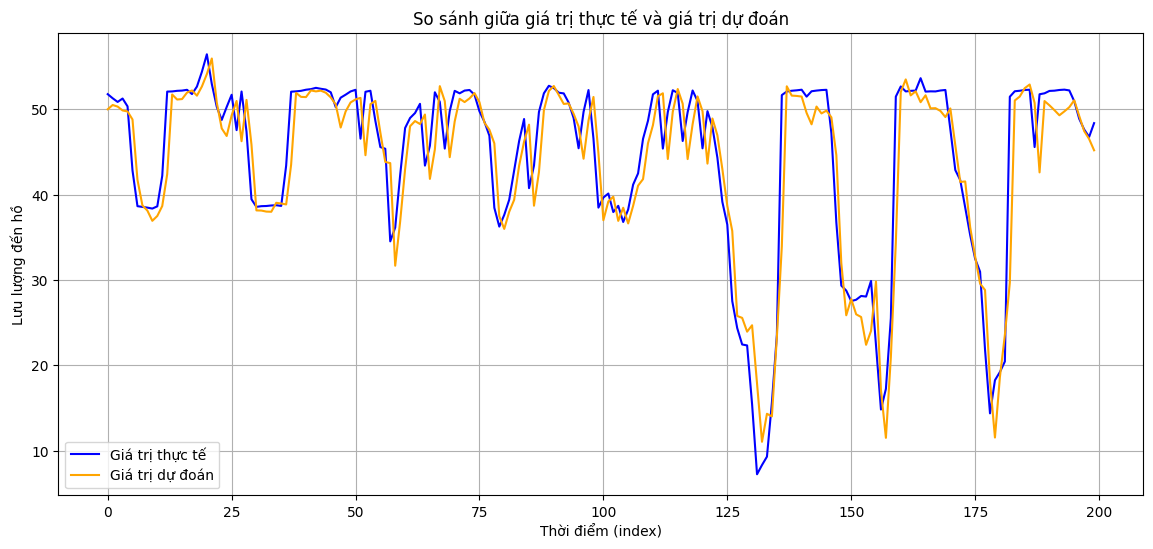

In [12]:
def main():
    """Main fine-tuning pipeline"""
    print("=== CHRONOS FINE-TUNING FOR HYDROLOGY DATA ===\n")
    
    # 1. Load data
    df = load_and_preprocess_data()
    if df is None:
        return
    
    # 2. Load Chronos model
    pipeline, model, tokenizer = setup_chronos_for_finetuning()
    if pipeline is None:
        return
    
    # 3. Create time series dataset
    print("\n📊 Creating time series dataset...")
    X, y, scaler = create_time_series_dataset(df, target_col="luu_luong_den_ho", 
                                            sequence_length=24, prediction_length=1)
    
    print(f"Dataset created: X shape {X.shape}, y shape {y.shape}")
    
    # 4. Train/validation split
    split_idx = int(len(X) * 0.8)
    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]
    
    print(f"Train: {len(X_train)} samples, Validation: {len(X_val)} samples")
    
    # 5. Fine-tune model
    fine_tuner, train_losses, val_losses = fine_tune_chronos(
        pipeline, model, tokenizer, X_train, y_train, X_val, y_val,
        num_epochs=30, batch_size=32, learning_rate=0.001
    )
    
    # 6. Evaluate model
    mse, rmse, mae, r2, predictions, actuals = evaluate_fine_tuned_model(
        fine_tuner, X_val, y_val, scaler
    )
    
    # 7. Print results
    print(f"\n" + "="*60)
    print("FINE-TUNED CHRONOS EVALUATION RESULTS")
    print("="*60)
    print(f"📊 Performance Metrics:")
    print(f"   MSE  (Mean Squared Error):     {mse:.6f}")
    print(f"   RMSE (Root Mean Squared Error): {rmse:.6f}")
    print(f"   MAE  (Mean Absolute Error):    {mae:.6f}")
    print(f"   R²   (R-squared):              {r2:.6f}")
    
    print(f"\n📈 Training Summary:")
    print(f"   Total epochs: {len(train_losses)}")
    print(f"   Final train loss: {train_losses[-1]:.6f}")
    print(f"   Final val loss: {val_losses[-1]:.6f}")
    print(f"   Best val loss: {min(val_losses):.6f}")
    
    # 8. Save model and results
    save_dir, timestamp = save_fine_tuned_model(
        fine_tuner, mse, rmse, mae, r2, predictions, actuals, 
        train_losses, val_losses
    )
    
    if save_dir:
        print(f"\n🎉 Fine-tuning completed successfully!")
        print(f"📁 Results saved in: {save_dir}")
        print(f"🔖 Timestamp: {timestamp}")

    # Vẽ biểu đồ so sánh
    plot_predictions(actuals, predictions, save_path="chronos_finetuned_1h/prediction_plot.png")

if __name__ == "__main__":
    main()

In [14]:
import json
with open(r'chronos_finetuned_1h\finetuned_results_20250606_182757.json') as f:
    results = json.load(f)

print("📊 Final Metrics:")
print(f"MSE: {results['metrics']['mse']:.6f}")
print(f"RMSE: {results['metrics']['rmse']:.6f}")  
print(f"MAE: {results['metrics']['mae']:.6f}")
print(f"R²: {results['metrics']['r2']:.6f}")

print(f"\n📈 Training completed in {results['training_history']['num_epochs']} epochs")

📊 Final Metrics:
MSE: 32.549778
RMSE: 5.705241
MAE: 3.202532
R²: 0.949217

📈 Training completed in 30 epochs


In [16]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import pandas as pd

def simple_predict(input_values):
    """
    Hàm dự đoán đơn giản thô
    
    Args:
        input_values: list hoặc array của 24 giá trị lưu lượng liên tiếp
    
    Returns:
        float: giá trị dự đoán
    """
    
    # 1. Load model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Tạo lại model architecture
    model = nn.Sequential(
        nn.Linear(24, 128),
        nn.ReLU(),
        nn.Dropout(0.1),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 1)
    ).to(device)
    
    # Load weights (thay đổi path nếu cần)
    model.load_state_dict(torch.load('chronos_finetuned_1h/chronos_finetuned_20250606_182757.pth', map_location=device))
    model.eval()
    
    # 2. Tạo scaler (từ data gốc)
    # Load data để tạo scaler
    ankhe_df = pd.read_csv("AnKhe.csv")
    ankhe_df["datetime"] = pd.to_datetime(ankhe_df["gio"].astype(str) + " " + ankhe_df["ngay"], format="%H %d/%m/%Y", errors='coerce')
    target_values = ankhe_df["luu_luong_den_ho"].dropna().values
    
    scaler = StandardScaler()
    scaler.fit(target_values.reshape(-1, 1))
    
    # 3. Chuẩn hóa input
    input_array = np.array(input_values)
    input_scaled = scaler.transform(input_array.reshape(-1, 1)).flatten()
    
    # 4. Dự đoán
    input_tensor = torch.FloatTensor(input_scaled).unsqueeze(0).to(device)
    
    with torch.no_grad():
        prediction_scaled = model(input_tensor).squeeze().cpu().numpy()
    
    # 5. Denormalize
    prediction = scaler.inverse_transform([[prediction_scaled]])[0][0]
    
    return prediction

# ==========================================
# CÁCH SỬ DỤNG
# ==========================================

# Ví dụ 1: Dữ liệu thô
data = [15.2, 16.1, 14.8, 15.7, 16.3, 15.9, 14.5, 15.1, 16.8, 15.4, 14.9, 15.6, 16.2, 15.8, 14.7, 15.3, 16.5, 15.1, 14.6, 15.9, 16.1, 15.5, 14.8, 15.4]
result = simple_predict(data)
print(f"Dự đoán: {result}")

# Ví dụ 2: Nhập từ bàn phím
def quick_input_predict():
    print("Nhập 24 giá trị (cách nhau bởi space):")
    input_str = input()
    values = [float(x) for x in input_str.split()]
    
    if len(values) != 24:
        print(f"Cần 24 giá trị, bạn nhập {len(values)}")
        return
    
    result = simple_predict(values)
    print(f"Kết quả: {result:.4f}")

# Chạy để test
# quick_input_predict()

Dự đoán: 15.910755732029273
